In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
import json

import nltk

nltk.download("vader_lexicon")
from nltk.sentiment import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\a\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [15]:
course_eval_df = pd.read_csv("UofT-Course-Data/data/course_evals.csv")
rmf_ratings_df = pd.read_csv("UofT-Course-Data/data/ratings.csv")
rmf_df = pd.read_csv("UofT-Course-Data/data/ratemyprof.csv")

with open("UofT-Course-Data/data/prof_mapping.json") as f:
    prof_mapping = json.load(f)

course_eval_df["avg_INS"] = course_eval_df[
    ["INS1","INS2","INS3","INS4","INS5","INS6"]
].mean(axis=1)

course_eval_df["avg_ARTSC"] = course_eval_df[
    ["ARTSC1","ARTSC2","ARTSC3"]
].mean(axis=1)

In [8]:
print("Course Evals:")
print(course_eval_df.describe())
print("RMF Ratings:")
print(rmf_ratings_df.describe())
print("RMF")
print(rmf_df.describe())

Course Evals:
               year          INS1          INS2          INS3          INS4  \
count  44400.000000  44400.000000  44400.000000  44398.000000  44400.000000   
mean    2018.644932      4.129769      4.231729      4.212006      4.020767   
std        3.778435      0.506392      0.485906      0.598239      0.528652   
min     2012.000000      1.600000      1.300000      1.000000      1.200000   
25%     2015.000000      3.800000      4.000000      3.900000      3.700000   
50%     2019.000000      4.200000      4.300000      4.300000      4.100000   
75%     2022.000000      4.500000      4.600000      4.700000      4.400000   
max     2025.000000      5.000000      5.000000      5.000000      5.000000   

               INS5          INS6        ARTSC1        ARTSC2        ARTSC3  \
count  44400.000000  44400.000000  40860.000000  44193.000000  44200.000000   
mean       4.052291      3.903515      4.282142      3.323484      3.913545   
std        0.531481      0.626463    

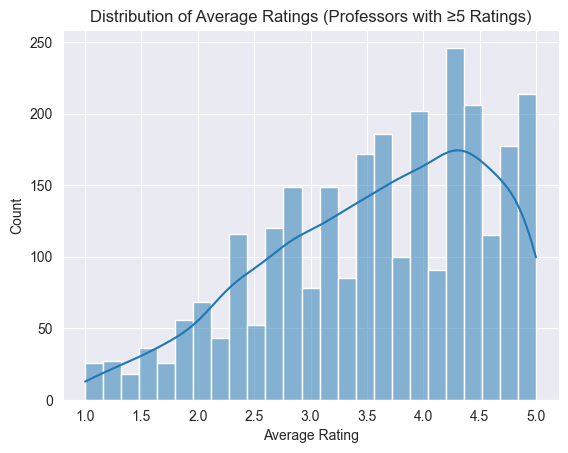

In [13]:
plt.figure()
sns.histplot(rmf_df[rmf_df["numRatings"] >= 5]["avgRating"], bins=25, kde=True)
plt.title("Distribution of Average Ratings (Professors with ≥5 Ratings)")
plt.xlabel("Average Rating")
plt.ylabel("Count")
plt.show()

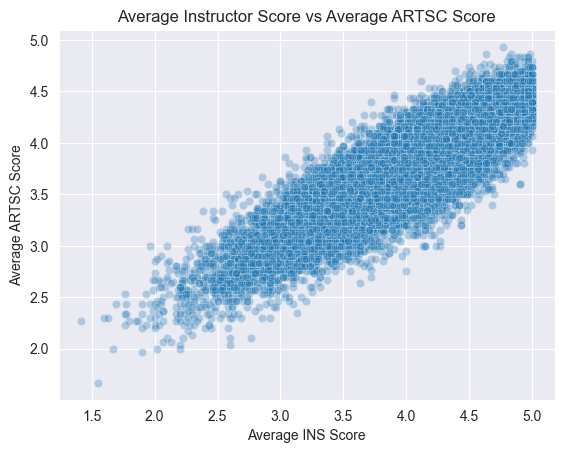

In [16]:
plt.figure()
sns.scatterplot(
    data=course_eval_df,
    x="avg_INS",
    y="avg_ARTSC",
    alpha=0.3
)

plt.title("Average Instructor Score vs Average ARTSC Score")
plt.xlabel("Average INS Score")
plt.ylabel("Average ARTSC Score")

plt.show()

In [23]:
predictors = ["INS1","INS2","INS3","INS4","INS5","INS6",
              "ARTSC1","ARTSC2","ARTSC3"]

X = course_eval_df[predictors]
X = sm.add_constant(X)

successes = course_eval_df["number_responses"]
trials = course_eval_df["number_invited"]
y = pd.concat([successes, trials - successes], axis=1)

mask = X.notna().all(axis=1) & y.notna().all(axis=1)
X_clean = X[mask]
y_clean = y[mask]


glm_binom = sm.GLM(y_clean, X_clean, family=sm.families.Binomial())
results = glm_binom.fit()

print(results.summary())

odds_ratios = np.exp(results.params)
print("Odds ratios:\n", odds_ratios)

                    Generalized Linear Model Regression Results                    
Dep. Variable:     ['number_responses', 0]   No. Observations:                40853
Model:                                 GLM   Df Residuals:                    40843
Model Family:                     Binomial   Df Model:                            9
Link Function:                       Logit   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:            -2.2354e+05
Date:                     Tue, 10 Mar 2026   Deviance:                   2.8009e+05
Time:                             23:52:35   Pearson chi2:                 2.75e+05
No. Iterations:                          4   Pseudo R-squ. (CS):             0.2586
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
co

In [25]:
residual_deviance = results.deviance
null_deviance = results.null_deviance
pseudo_r2 = 1 - residual_deviance / null_deviance
print(residual_deviance, null_deviance, pseudo_r2)

280087.94756881543 292310.6281287868 0.04181401353147607
